이 문서는 라쉬 측정 이론(Rasch Measurement Theory, RMT)의 기초 모델부터 다면 평가 및 설명적 문항 반응 이론(EIRT)으로의 확장형까지를 정리한 가이드입니다.  (with Gemini 3.1 Thinking)

---

# Rasch Measurement Theory: From Basic to Explanatory Models

## 1. Rasch Model (Dichotomous)
가장 기초적인 모델로, 응답 결과가 이분형(맞음/틀림, 예/아니오)일 때 사용합니다. 피험자의 능력과 문항의 난이도라는 두 가지 파라미터만으로 응답 확률을 예측합니다.

### Equation
피험자 $n$이 문항 $i$에서 정답($1$)을 맞힐 확률 $P_{ni1}$의 로짓(Logit)은 다음과 같습니다.

\begin{align}
    \ln \left( \frac{P_{ni1}}{1 - P_{ni1}} \right) & = \theta_n - \beta_i 
    \\
    & = \ln \left( \frac{P(Y_{ni}=1)}{1 - P(Y_{ni}=1)} \right) 
    \\
    & = \ln \left( \frac{P(Y_{ni}=1)}{P(Y_{ni}=0)} \right)
    \\
    & = \ln \left( \frac{P_{ni1}}{P_{ni0}} \right)
\end{align}

* $\theta_n$: 피험자 $n$의 능력 (Ability)
* $\beta_i$: 문항 $i$의 난이도 (Item Difficulty)



---

## 2. Partial Credit Model (PCM)
이분형 모델을 다분 문항(Polytomous, 예: 리커트 척도)으로 확장한 모델입니다. 각 문항이 고유한 단계 난이도 구조를 가질 수 있다고 가정합니다.

### A. Combined Form (결합형)
각 임계치(Threshold)의 절대적 위치에 집중할 때 사용합니다.

$$\ln \left( \frac{P_{nik}}{P_{ni(k-1)}} \right) = \theta_n - b_{ik}$$

* $b_{ik}$: 문항 $i$의 $k$번째 단계가 가진 절대적 난이도 지점 ($b_{ik} = \beta_i + \tau_{ik}$)

### B. Decomposed Form (분해형)
문항의 전반적인 위치($\beta$)와 각 점수 단계별 편차($\tau$)를 분리하여 해석할 때 유리하며, **EIRT 확장 시 표준**으로 사용됩니다.

$$\ln \left( \frac{P_{nik}}{P_{ni(k-1)}} \right) = \theta_n - (\beta_i + \tau_{ik})$$

* $\beta_i$: 문항 $i$의 전반적(평균적) 어려움
* $\tau_{ik}$: 문항 $i$ 내에서 단계 $k-1$에서 $k$로 넘어가기 위한 상대적 어려움 (Step Difficulty)
* **Constraint**: $\sum_{k=1}^m \tau_{ik} = 0$ (문항별로 적용)




---

## 3. Many-Facet Rasch Model (MFRM)
피험자와 문항 외에 **채점자(Rater)의 엄격성**이나 평가 상황 등 제3의 요인을 모델에 포함합니다. 주로 모든 문항이 동일한 척도 구조($\tau_k$)를 공유한다고 가정합니다.

### Equation
$$\ln \left( \frac{P_{nijk}}{P_{nij(k-1)}} \right) = \theta_n - \beta_i - \rho_j - \tau_k$$

* $\rho_j$: 채점자 $j$의 엄격성 (Severity)
* $\tau_k$: 모든 문항에 공통으로 적용되는 단계 $k$의 난이도 (MFPCM의 단순화 형태)



---

## 4. Many-Facet Partial Credit Model (MFPCM)
MFRM에 PCM의 유연성을 결합한 모델입니다. 채점자 효과를 통제하면서도, **각 문항마다 서로 다른 단계 구조**를 가질 수 있도록 허용합니다. `FACETS` 소프트웨어에서 `Models= ?,?B,?,R#` 설정을 통해 구현하는 모델이 바로 이 형태입니다.

### Equation
$$\ln \left( \frac{P_{nijk}}{P_{nij(k-1)}} \right) = \theta_n - \beta_i - \rho_j - \tau_{ik}$$

* $\tau_{ik}$: 문항 $i$에 특수한 단계 $k$의 난이도

---

## 5. PCM with Double Explanatory Model (EIRT)
잠재 변수인 능력($\theta$)과 난이도($\beta$)를 관측 가능한 외부 변수(Covariates)로 설명하는 가장 진보된 형태입니다.

### Structural Equations
1.  **Person-side**: 피험자 속성 $Z$에 의한 능력 설명
    $$\theta_n = \sum_{q=1}^Q \alpha_q Z_{nq} + \zeta_n, \quad \zeta_n \sim N(0, \sigma_\theta^2)$$
2.  **Item-side (LLTM)**: 문항 속성 $X$에 의한 난이도 설명
    $$\beta_i = \sum_{p=1}^P \gamma_p X_{ip} + \epsilon_i, \quad \epsilon_i \sim N(0, \sigma_\beta^2)$$

### Total Integrated Logit Form
$$\ln \left( \frac{P_{nik}}{P_{ni(k-1)}} \right) = \left( \sum \alpha_q Z_{nq} + \zeta_n \right) - \left( \sum \gamma_p X_{ip} + \epsilon_i + \tau_{ik} \right)$$

* 이 모델은 **"어떤 문항 특성이 난이도를 높이는가?"**와 **"어떤 피험자 특성이 능력을 결정하는가?"**를 동시에 검증할 수 있습니다.



---

## 6. Implementation Note: Bayesian Approach (Stan)
전통적인 `FACETS`나 `R` 패키지와 달리, **Stan**을 이용한 베이지안 추정은 다음과 같은 강점이 있습니다.

* **Fit Analysis**: `generated quantities` 블록을 통해 **Infit/Outfit MNSQ**의 사후 분포를 산출하여 리뷰어의 적합도 요구에 대응 가능.
* **PPC (Posterior Predictive Checking)**: 모델이 생성한 가상 데이터와 실제 데이터를 비교하여 모델 타당성 시각화.
* **Flexibility**: Double Explanatory 구조와 같은 복잡한 선형 결합을 자유롭게 설계하고, Prior를 통해 추정의 안정성 확보.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

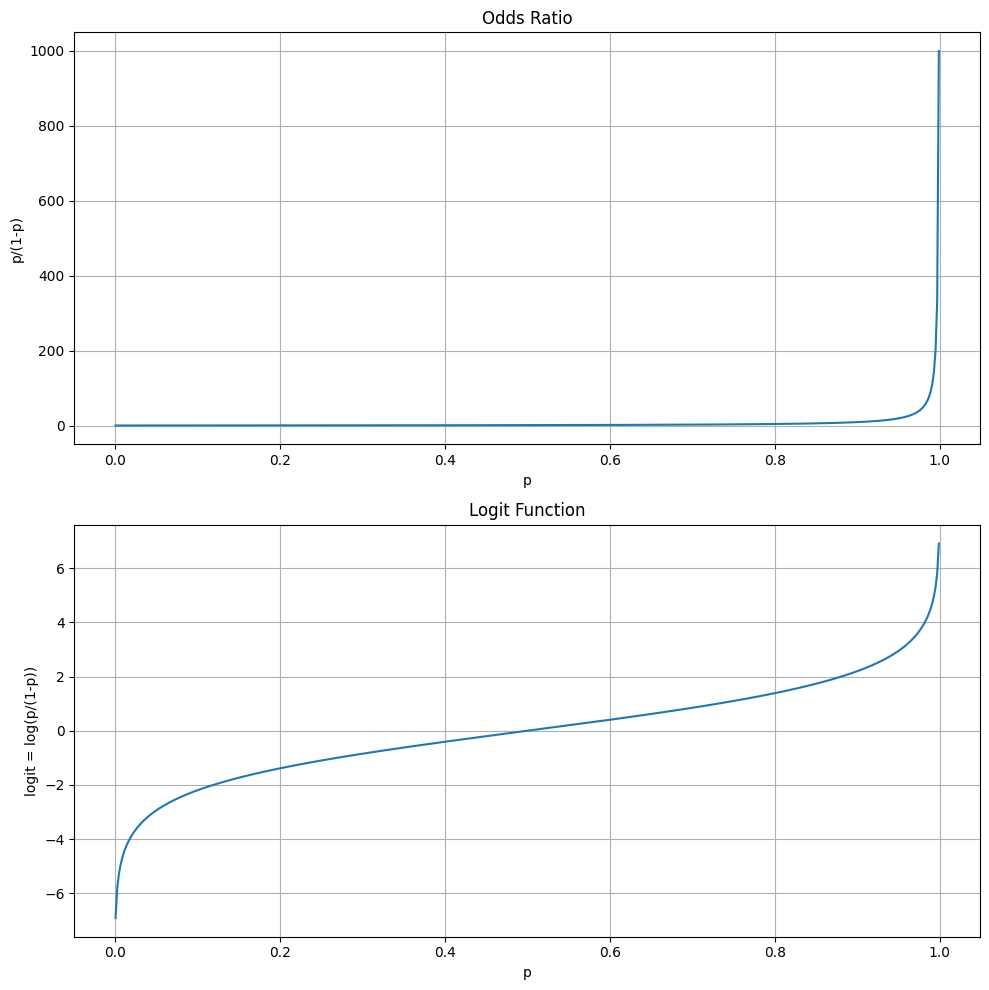

In [6]:
p = np.linspace(0.001, 0.999, 500)
p_ratio = p / (1 - p)
logit = np.log(p_ratio)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))
sns.lineplot(x=p, y=p_ratio, ax=axes[0])
axes[0].set_xlabel('p')
axes[0].set_ylabel('p/(1-p)')
axes[0].set_title('Odds Ratio')
axes[0].grid(True)

sns.lineplot(x=p, y=logit, ax=axes[1])
axes[1].set_xlabel('p')
axes[1].set_ylabel('logit = log(p/(1-p))')
axes[1].set_title('Logit Function')
axes[1].grid(True)
plt.tight_layout()
plt.show()